In [1]:
from spin_lattices import KagomeLattice, SpinLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from boolean_analysis import (
    BooleanFourierAnalyzer,
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    SignalOption,
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
)
from boolean_fourier_learner import BooleanFourierLearner

from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse

from parity import popcount, parity

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data

import pickle

ground_state_cache_dir = Path("groundstates")
fourier_learners_cache_dir = Path("fourier_learners_cache")
experiments_dir = Path("experiments") / "kagome-24-nn-2023-01-26-2"
experiments_dir.mkdir(parents=True, exist_ok=True)

2023-01-26 20:26:07.946 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-01-26 20:26:07.952 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
[Debug]   [LOCALE0]   Initializing chpl_kernels ...
2023-01-26 20:26:08.006 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
set_python_exception_handler ...


In [2]:
J2 = 1
system = HeisenbergJ1J2(
    lattice=KagomeLattice(width=2, height=4),
    J1=1,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=ground_state_cache_dir,
    show_progress=True,
)
system.get_eigenstates(1)
analyzer = BooleanFourierAnalyzer(
    system=system,
    use_subset_symmetries=True,
    show_progress=True,
    cache_dir=fourier_learners_cache_dir,
)


number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763
Making Fourier basis state info with symmetries...
MFBSIS: Building Fourier basis...


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


MFBSIS: Computing state info...
MFBSIS: Computing sign flip basis correspondence...
MFBSIS: Computing fourier_basis_state_info_df...
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763


In [3]:
df = (
    system.get_df_ground_state(
        canonical_basis=True, unpack_configurations=True, expand_basis_columns=True
    )
    .assign(
        sign=(lambda df: np.sign(df["eigenstate_coeff"])),
        prob=(lambda df: np.abs(df["eigenstate_coeff"]) ** 2),
    )
    .assign(y=lambda df: (df["sign"] == 1).astype(int))
)


In [4]:
analyzer.fit(
    analyzer.system.canonical_basis.states, signal_opt=SignalOption(kind=SignSignalKind())
)


Restoring learner from cache: fourier_learners_cache/485a7e675a16d4a5bd22ed3c02de8f6f-HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=0, weights=uniform_weights).lz


In [5]:
subsets = np.random.choice(analyzer.learner.get_coeffs_ser().iloc[:100].index, 3)

In [6]:
subsets

array([1284557,  845625, 1692908], dtype=uint64)

In [7]:
for subset in subsets:
    df[f"parity_{subset}"] = parity(np.asarray(df.index, dtype='uint64') & subset)

In [8]:
df

,eigenstate_coeff,amplitude,s0,s1,s2,s3,s4,s5,s6,s7,...,s20,s21,s22,s23,sign,prob,y,parity_1284557,parity_845625,parity_1692908
4095,6.520253e-08,6.520253e-08,1,1,1,1,1,1,1,1,...,0,0,0,0,1.0,4.251370e-15,1,1,1,0
6143,1.917753e-08,1.917753e-08,1,1,1,1,1,1,1,1,...,0,0,0,0,1.0,3.677777e-16,1,1,1,1
7167,-1.202650e-19,1.202650e-19,1,1,1,1,1,1,1,1,...,0,0,0,0,-1.0,1.446366e-38,0,0,0,0
7679,-1.983175e-07,1.983175e-07,1,1,1,1,1,1,1,1,...,0,0,0,0,-1.0,3.932984e-14,0,0,0,1
7935,-2.243748e-07,2.243748e-07,1,1,1,1,1,1,1,1,...,0,0,0,0,-1.0,5.034404e-14,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16769280,-2.243748e-07,2.243748e-07,0,0,0,0,0,0,0,0,...,1,1,1,1,-1.0,5.034404e-14,0,1,0,1
16769536,-1.983175e-07,1.983175e-07,0,0,0,0,0,0,0,0,...,1,1,1,1,-1.0,3.932984e-14,0,0,0,1
16770048,-1.202650e-19,1.202650e-19,0,0,0,0,0,0,0,0,...,1,1,1,1,-1.0,1.446366e-38,0,0,0,0
16771072,1.917753e-08,1.917753e-08,0,0,0,0,0,0,0,0,...,1,1,1,1,1.0,3.677777e-16,1,1,1,1


In [9]:
eps_train = 2e-3
val_eps = 1e-2
test_eps = 1e-2
batch_size = 64

df_train = df.sample(frac=eps_train, weights="prob")
df_val = df.sample(frac=val_eps, weights="prob")
df_test = df.sample(frac=test_eps, weights="prob")

n_batches = int(np.ceil(len(df_train) / batch_size))
epochs = 20000


In [18]:
features = [f"s{i}" for i in range(system.number_spins)] + [f"parity_{subset}" for subset in subsets[:1]]

net = nn.Sequential(
    nn.Linear(len(features), 64),
    nn.ReLU(),
    nn.Linear(64, 2),
)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)


In [19]:
def get_inputs_and_labels(df: pd.DataFrame) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    X = torch.tensor(df[features].values.astype("float"), dtype=torch.float32)
    y = torch.tensor(df["y"].values.astype("int8"), dtype=torch.long)
    probs = torch.tensor(df["prob"].values.astype("float"), dtype=torch.float32)
    return X, y, probs


inputs_val, labels_val, probs_val = get_inputs_and_labels(df_val)


In [20]:
def evaluate(net, inputs, labels, probs):
    with torch.no_grad():
        outputs = net(inputs)
        _, predicted = torch.max(outputs.data, 1)
        correct = (predicted == labels).sum().item()
        accuracy = correct / len(labels)

        sign_overlap = (
            ((predicted * 2 - 1) * (labels * 2 - 1) * probs).sum() / probs.sum()
        ).item()
        return accuracy, sign_overlap


In [21]:
for epoch in range(epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    i = None
    loss = None

    for i in range(n_batches):
        data = df_train.iloc[i * batch_size : (i + 1) * batch_size]
        inputs, labels, probs = get_inputs_and_labels(data)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f"[{epoch + 1}, {i}] loss: {loss}")

    accuracy, sign_overlap = evaluate(net, inputs, labels, probs)
    print(f"Test set: accuracy: {100 * accuracy} %, sign overlap: {sign_overlap}")

    accuracy_val, sign_overlap_val = evaluate(net, inputs_val, labels_val, probs_val)
    print(f"Validation set: accuracy: {100 * accuracy_val} %, sign overlap: {sign_overlap_val}")


[1, 84] loss: 0.700451135635376
Test set: accuracy: 50.0 %, sign overlap: 0.29943913221359253
Validation set: accuracy: 50.876414466385626 %, sign overlap: 0.0395372249186039
[2, 84] loss: 0.6965912580490112
Test set: accuracy: 59.375 %, sign overlap: -0.1734783798456192
Validation set: accuracy: 51.40152355595 %, sign overlap: 0.051237430423498154
[3, 84] loss: 0.6926295757293701
Test set: accuracy: 56.25 %, sign overlap: -0.17690078914165497
Validation set: accuracy: 51.730641224761484 %, sign overlap: 0.05926532298326492
[4, 84] loss: 0.6876890659332275
Test set: accuracy: 56.25 %, sign overlap: -0.17690078914165497
Validation set: accuracy: 51.952518304859105 %, sign overlap: 0.06844398379325867
[5, 84] loss: 0.68422532081604
Test set: accuracy: 53.125 %, sign overlap: -0.22672410309314728
Validation set: accuracy: 52.22246875231122 %, sign overlap: 0.07027589529752731
[6, 84] loss: 0.6810179352760315
Test set: accuracy: 53.125 %, sign overlap: -0.22672410309314728
Validation set: 

KeyboardInterrupt: 

Restoring learner from cache: fourier_learners_cache/485a7e675a16d4a5bd22ed3c02de8f6f-HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-SignalOption(kind=SignSignalKind, eigenstate=0, weights=uniform_weights).lz


<AxesSubplot: >

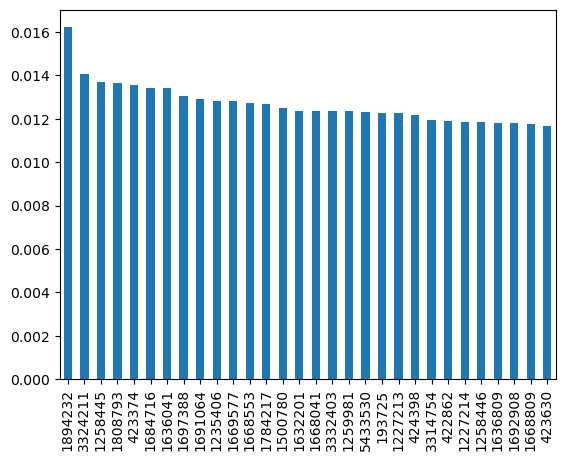

In [118]:
np.abs(analyzer.learner.get_coeffs_ser().iloc[:30]).plot.bar()


In [120]:
nn_fourier_learner = BooleanFourierLearner(system.number_spins, analyzer.subsets)


In [121]:
full_inputs, _, _ = get_inputs_and_labels(df)


In [125]:
with torch.no_grad():
    nn_full_prediction = torch.max(net(full_inputs), 1)[1].numpy()


In [128]:
df.index


UInt64Index([    4095,     6143,     7167,     7679,     7935,     8063,
                 8127,     8159,     8175,     8183,
             ...
             16769032, 16769040, 16769056, 16769088, 16769152, 16769280,
             16769536, 16770048, 16771072, 16773120],
            dtype='uint64', length=2704156)

In [129]:
nn_fourier_learner.fit(
    np.asarray(df.index, dtype="uint64"),
    nn_full_prediction * 2 - 1,
    batch_size=1000,
    show_progress=True,
)


100%|██████████| 2705/2705 [1:15:18<00:00,  1.67s/it]


<AxesSubplot: >

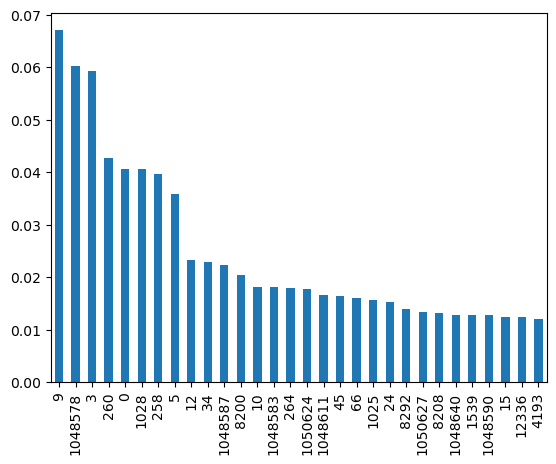

In [130]:
np.abs(nn_fourier_learner.get_coeffs_ser().iloc[:30]).plot.bar()


In [132]:
popcount(np.asarray(nn_fourier_learner.get_coeffs_ser().iloc[:30].index, dtype="uint64"))

array([2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 4, 2, 2, 4, 2, 2, 4, 4, 2, 2, 2, 4,
       4, 2, 2, 4, 4, 4, 4, 4], dtype=uint8)

In [133]:
nn_fourier_learner.get_coeffs_ser()

9          0.067073
1048578    0.060150
3          0.059258
260       -0.042638
0          0.040637
             ...   
1182759    0.000000
287543     0.000000
1190865    0.000000
1059010    0.000000
1443698    0.000000
Name: coeff, Length: 264976, dtype: float64

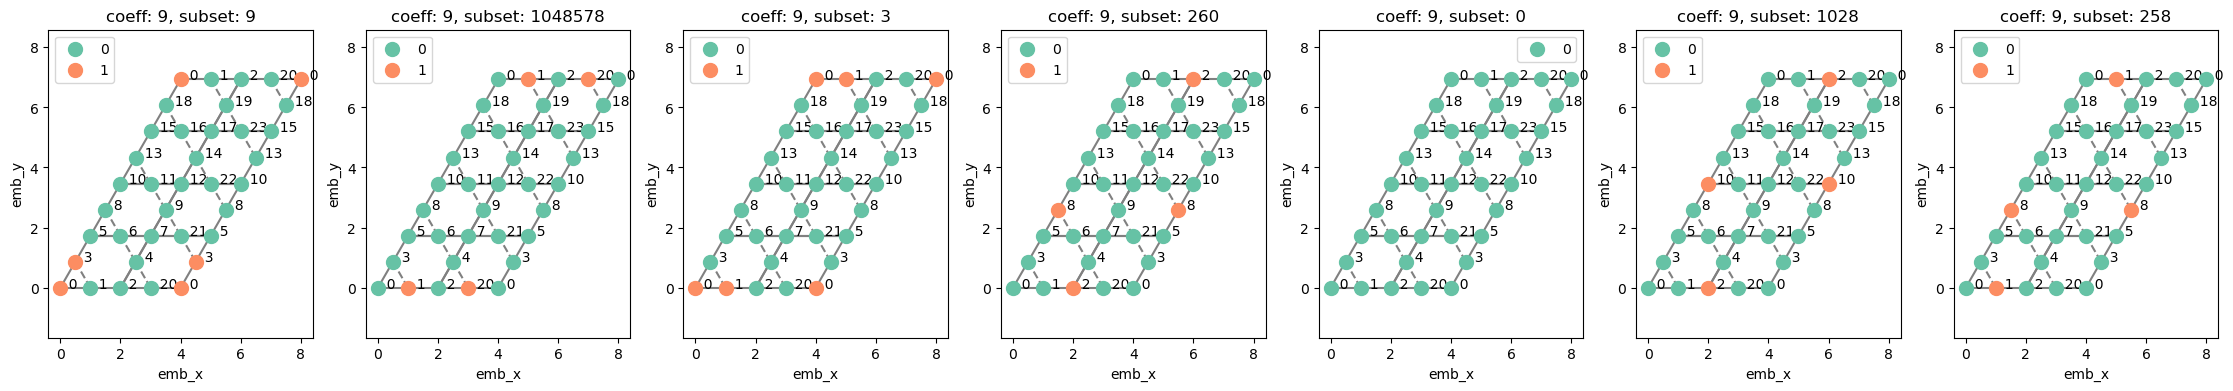

In [140]:
fix, ax = plt.subplots(ncols=7, figsize=(7 * 4, 4))
for i, subset in enumerate(nn_fourier_learner.get_coeffs_ser().iloc[:7].index):
    ax[i].set_title(f"coeff: {coeff}, subset: {subset}")
    analyzer.system.lattice.plot(spins=subset, ax=ax[i])

In [145]:
with open(experiments_dir / "nn_fourier_learner.pkl", "wb") as f:
    pickle.dump(nn_fourier_learner, f)

In [146]:
torch.save(net.state_dict(), experiments_dir / "nn_model.pt")